In [1]:
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pymannkendall as mk

from scipy.stats import pearsonr

In [2]:
PROJECT = os.path.dirname(os.getcwd())

MASTER = os.path.join(PROJECT, "Master_dataset")

RESULTS = os.path.join(PROJECT, "Results")

os.makedirs(RESULTS, exist_ok=True)

In [4]:
SEAICE_FILE = os.path.join(
    MASTER,
    "Yearly_Average_Sea_Ice.xlsx"
)

ALBEDO_FILE = os.path.join(
    MASTER,
    "Albedo_Statistics_2000_2026 (1).xlsx"
)

seaice = pd.read_excel(SEAICE_FILE)

albedo = pd.read_excel(
    ALBEDO_FILE,
    sheet_name="Yearly_albedo_statistics"
)

In [5]:
seaice = seaice[seaice["Year"] <= 2025].copy()

albedo = albedo[albedo["Year"] <= 2025].copy()

In [24]:
df = pd.merge(
    seaice,
    albedo,
    on="Year"
)

df

,Year,March,April,May,June,July,August,September,Yearly Mean,Minimum,Maximum,Standard Deviation,Ocean Mean Albedo,Land Mean Albedo,Overall Mean Albedo
0,2000,12.827,12.781,12.217,11.168,9.518,7.251,6.361,10.303,6.361,12.827,2.658,0.4890,0.3916,0.4541
1,2001,13.032,12.991,12.403,11.224,9.281,7.526,6.778,10.462,6.778,13.032,2.612,0.4980,0.3917,0.4599
2,2002,12.957,12.663,12.112,11.088,9.358,6.565,5.981,10.103,5.981,12.957,2.880,0.4835,0.3865,0.4487
3,2003,12.960,12.805,12.157,11.286,9.386,6.931,6.184,10.244,6.184,12.960,2.795,0.4770,0.3764,0.4409
4,2004,12.914,12.615,11.778,10.991,9.297,6.834,6.082,10.073,6.082,12.914,2.748,0.4933,0.3953,0.4582
5,2005,12.707,12.653,12.119,10.884,8.987,6.324,5.593,9.895,5.593,12.707,2.987,0.4768,0.3821,0.4428
6,2006,12.595,12.491,11.752,10.600,8.688,6.557,5.949,9.805,5.949,12.595,2.771,0.4823,0.3875,0.4483
7,2007,12.408,12.341,11.878,10.906,8.182,5.402,4.324,9.349,4.324,12.408,3.399,0.4481,0.3800,0.4237
8,2008,12.666,12.605,12.135,10.885,8.826,6.066,4.737,9.703,4.737,12.666,3.245,0.4574,0.3867,0.4321
9,2009,12.765,12.819,12.326,10.819,8.520,6.276,5.388,9.845,5.388,12.819,3.131,0.4662,0.3846,0.4369


In [8]:
# ============================================================
# LONG-TERM MEAN (2000–2025)
# ============================================================

sea_mean = df["Yearly Mean"].mean()

albedo_mean = df["Ocean Mean Albedo"].mean()

print("="*50)
print("LONG TERM MEAN")
print("="*50)
print(f"Sea Ice Mean        : {sea_mean:.3f} Million km²")
print(f"Ocean Albedo Mean   : {albedo_mean:.4f}")

LONG TERM MEAN
Sea Ice Mean        : 9.614 Million km²
Ocean Albedo Mean   : 0.4577


Cell 8 — Calculate Percentage Deviation

Use the formula your guide gave:

Long-Term Mean
Yearly Mean−Long-Term Mean
	​

×100

In [9]:
# ============================================================
# PERCENTAGE DEVIATION
# ============================================================

df["Sea Ice Deviation (%)"] = (
    (df["Yearly Mean"] - sea_mean)
    / sea_mean
) * 100

df["Albedo Deviation (%)"] = (
    (df["Ocean Mean Albedo"] - albedo_mean)
    / albedo_mean
) * 100

df.head()

,Year,March,April,May,June,July,August,September,Yearly Mean,Minimum,Maximum,Standard Deviation,Ocean Mean Albedo,Land Mean Albedo,Overall Mean Albedo,Sea Ice Deviation (%),Albedo Deviation (%)
0,2000,12.827,12.781,12.217,11.168,9.518,7.251,6.361,10.303,6.361,12.827,2.658,0.4890,0.3916,0.4541,7.163631,6.834052
1,2001,13.032,12.991,12.403,11.224,9.281,7.526,6.778,10.462,6.778,13.032,2.612,0.4980,0.3917,0.4599,8.817423,8.800323
2,2002,12.957,12.663,12.112,11.088,9.358,6.565,5.981,10.103,5.981,12.957,2.880,0.4835,0.3865,0.4487,5.083390,5.632442
3,2003,12.960,12.805,12.157,11.286,9.386,6.931,6.184,10.244,6.184,12.960,2.795,0.4770,0.3764,0.4409,6.549960,4.212357
4,2004,12.914,12.615,11.778,10.991,9.297,6.834,6.082,10.073,6.082,12.914,2.748,0.4933,0.3953,0.4582,4.771353,7.773492


In [10]:
# ============================================================
# SAVE MASTER DATASET
# ============================================================

OUTPUT_FILE = os.path.join(
    RESULTS,
    "Trend_Analysis_Master_Dataset.xlsx"
)

df.to_excel(
    OUTPUT_FILE,
    index=False
)

print("Saved Successfully")
print(OUTPUT_FILE)

Saved Successfully
c:\Users\ACER\OneDrive\Desktop\ISRO\snow_2\Results\Trend_Analysis_Master_Dataset.xlsx


In [11]:
print(df.head())

print()

print(df.columns.tolist())

print()

print(df.shape)

   Year   March   April     May    June   July  August  September  \
0  2000  12.827  12.781  12.217  11.168  9.518   7.251      6.361   
1  2001  13.032  12.991  12.403  11.224  9.281   7.526      6.778   
2  2002  12.957  12.663  12.112  11.088  9.358   6.565      5.981   
3  2003  12.960  12.805  12.157  11.286  9.386   6.931      6.184   
4  2004  12.914  12.615  11.778  10.991  9.297   6.834      6.082   

   Yearly Mean  Minimum  Maximum  Standard Deviation  Ocean Mean Albedo  \
0       10.303    6.361   12.827               2.658             0.4890   
1       10.462    6.778   13.032               2.612             0.4980   
2       10.103    5.981   12.957               2.880             0.4835   
3       10.244    6.184   12.960               2.795             0.4770   
4       10.073    6.082   12.914               2.748             0.4933   

   Land Mean Albedo  Overall Mean Albedo  Sea Ice Deviation (%)  \
0            0.3916               0.4541               7.163631   


In [12]:
# ============================================================
# PEARSON CORRELATION
# ============================================================

from scipy.stats import pearsonr

r, p = pearsonr(
    df["Sea Ice Deviation (%)"],
    df["Albedo Deviation (%)"]
)

print("="*50)
print("PEARSON CORRELATION")
print("="*50)
print(f"Correlation (r) : {r:.3f}")
print(f"P-value         : {p:.6f}")

PEARSON CORRELATION
Correlation (r) : 0.937
P-value         : 0.000000


In [13]:
# ============================================================
# MANN-KENDALL TEST
# ============================================================

import pymannkendall as mk

sea_result = mk.original_test(df["Sea Ice Deviation (%)"])

alb_result = mk.original_test(df["Albedo Deviation (%)"])

print("="*60)
print("SEA ICE")
print("="*60)

print(sea_result)

print()

print("="*60)
print("ALBEDO")
print("="*60)

print(alb_result)

SEA ICE
Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(6.593688664424668e-05), z=np.float64(-3.990490153550879), Tau=np.float64(-0.56), s=np.float64(-182.0), var_s=np.float64(2057.3333333333335), slope=np.float64(-0.4363553791287409), intercept=np.float64(4.858773141493935))

ALBEDO
Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(0.00011422109125835966), z=np.float64(-3.8582087119967063), Tau=np.float64(-0.5415384615384615), s=np.float64(-176.0), var_s=np.float64(2057.3333333333335), slope=np.float64(-0.42056349626492556), intercept=np.float64(4.204164460914075))


In [14]:
# ============================================================
# SUMMARY TABLE
# ============================================================

summary = pd.DataFrame({

    "Variable":[
        "Sea Ice",
        "Ocean Mean Albedo"
    ],

    "Trend":[
        sea_result.trend,
        alb_result.trend
    ],

    "Sen's Slope":[
        sea_result.slope,
        alb_result.slope
    ],

    "Tau":[
        sea_result.Tau,
        alb_result.Tau
    ],

    "P-value":[
        sea_result.p,
        alb_result.p
    ]

})

summary

,Variable,Trend,Sen's Slope,Tau,P-value
0,Sea Ice,decreasing,-0.436355,-0.560000,0.000066
1,Ocean Mean Albedo,decreasing,-0.420563,-0.541538,0.000114


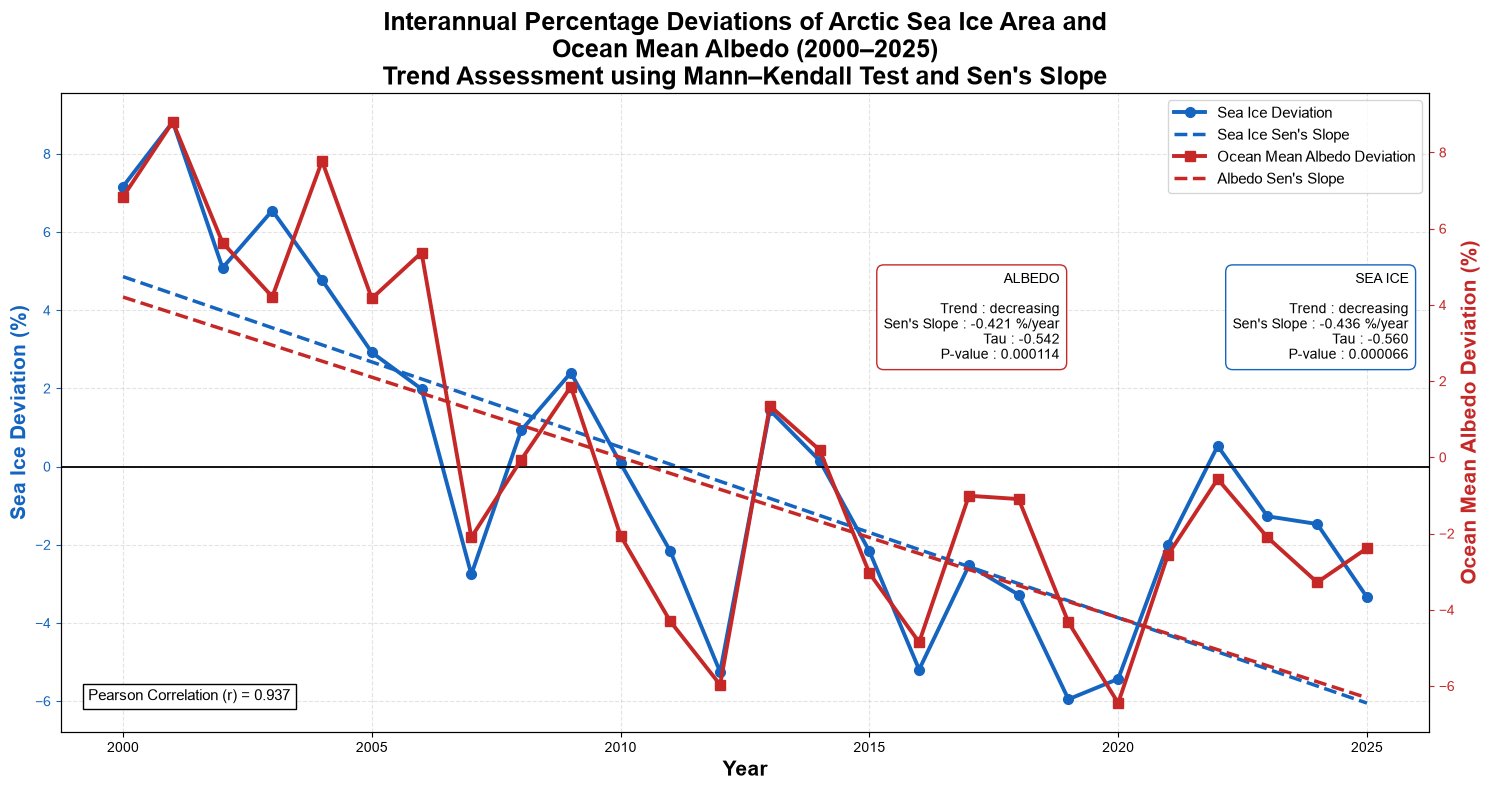

Publication Quality Figure Saved Successfully


In [15]:
# ============================================================
# PUBLICATION QUALITY FIGURE
# Mann–Kendall + Sen's Slope
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# ============================================================
# MANN-KENDALL
# ============================================================

sea_result = mk.original_test(df["Sea Ice Deviation (%)"])
alb_result = mk.original_test(df["Albedo Deviation (%)"])

# ============================================================
# SEN'S SLOPE TREND
# ============================================================

x = df["Year"].values
index = np.arange(len(df))

sea_sen = sea_result.intercept + sea_result.slope * index
alb_sen = alb_result.intercept + alb_result.slope * index

# ============================================================
# PEARSON CORRELATION
# ============================================================

corr = df["Sea Ice Deviation (%)"].corr(
    df["Albedo Deviation (%)"]
)

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(15,8))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(
    x,
    df["Sea Ice Deviation (%)"],
    marker="o",
    color="#1565C0",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Deviation"
)

ax1.plot(
    x,
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.5,
    label="Sea Ice Sen's Slope"
)

ax1.set_ylabel(
    "Sea Ice Deviation (%)",
    fontsize=15,
    color="#1565C0",
    fontweight="bold"
)

ax1.tick_params(
    axis="y",
    colors="#1565C0"
)

# ============================================================
# ZERO REFERENCE
# ============================================================

ax1.axhline(
    0,
    color="black",
    linewidth=1.3
)

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    df["Albedo Deviation (%)"],
    marker="s",
    color="#C62828",
    linewidth=2.8,
    markersize=7,
    label="Ocean Mean Albedo Deviation"
)

ax2.plot(
    x,
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.5,
    label="Albedo Sen's Slope"
)

ax2.set_ylabel(
    "Ocean Mean Albedo Deviation (%)",
    fontsize=15,
    color="#C62828",
    fontweight="bold"
)

ax2.tick_params(
    axis="y",
    colors="#C62828"
)

# ============================================================
# GRID
# ============================================================

ax1.grid(
    linestyle="--",
    alpha=0.35
)

# ============================================================
# LABELS
# ============================================================

ax1.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Interannual Percentage Deviations of Arctic Sea Ice Area and\n"
    "Ocean Mean Albedo (2000–2025)\n"
    "Trend Assessment using Mann–Kendall Test and Sen's Slope",
    fontsize=18,
    fontweight="bold"
)

# ============================================================
# LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    fontsize=11,
    frameon=True
)

# ============================================================
# SEA ICE BOX
# ============================================================

ax1.text(
    0.985,
    0.72,
    (
        "SEA ICE\n\n"
        f"Trend : {sea_result.trend}\n"
        f"Sen's Slope : {sea_result.slope:.3f} %/year\n"
        f"Tau : {sea_result.Tau:.3f}\n"
        f"P-value : {sea_result.p:.6f}"
    ),
    transform=ax1.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        boxstyle="round,pad=0.5"
    )
)

# ============================================================
# ALBEDO BOX
# ============================================================

ax2.text(
    0.73,
    0.72,
    (
        "ALBEDO\n\n"
        f"Trend : {alb_result.trend}\n"
        f"Sen's Slope : {alb_result.slope:.3f} %/year\n"
        f"Tau : {alb_result.Tau:.3f}\n"
        f"P-value : {alb_result.p:.6f}"
    ),
    transform=ax2.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        boxstyle="round,pad=0.5"
    )
)

# ============================================================
# CORRELATION BOX
# ============================================================

ax1.text(
    0.02,
    0.05,
    f"Pearson Correlation (r) = {corr:.3f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black"
    )
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS,
        "MK_Sen_SeaIce_Albedo_2000_2025.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("="*60)
print("Publication Quality Figure Saved Successfully")
print("="*60)

In [16]:
# ============================================================
# DATA : 2000-2015
# ============================================================

df_period = df[
    (df["Year"] >= 2000) &
    (df["Year"] <= 2015)
].copy()

print(df_period.shape)

print(df_period.head())

(16, 17)
   Year   March   April     May    June   July  August  September  \
0  2000  12.827  12.781  12.217  11.168  9.518   7.251      6.361   
1  2001  13.032  12.991  12.403  11.224  9.281   7.526      6.778   
2  2002  12.957  12.663  12.112  11.088  9.358   6.565      5.981   
3  2003  12.960  12.805  12.157  11.286  9.386   6.931      6.184   
4  2004  12.914  12.615  11.778  10.991  9.297   6.834      6.082   

   Yearly Mean  Minimum  Maximum  Standard Deviation  Ocean Mean Albedo  \
0       10.303    6.361   12.827               2.658             0.4890   
1       10.462    6.778   13.032               2.612             0.4980   
2       10.103    5.981   12.957               2.880             0.4835   
3       10.244    6.184   12.960               2.795             0.4770   
4       10.073    6.082   12.914               2.748             0.4933   

   Land Mean Albedo  Overall Mean Albedo  Sea Ice Deviation (%)  \
0            0.3916               0.4541               7.1

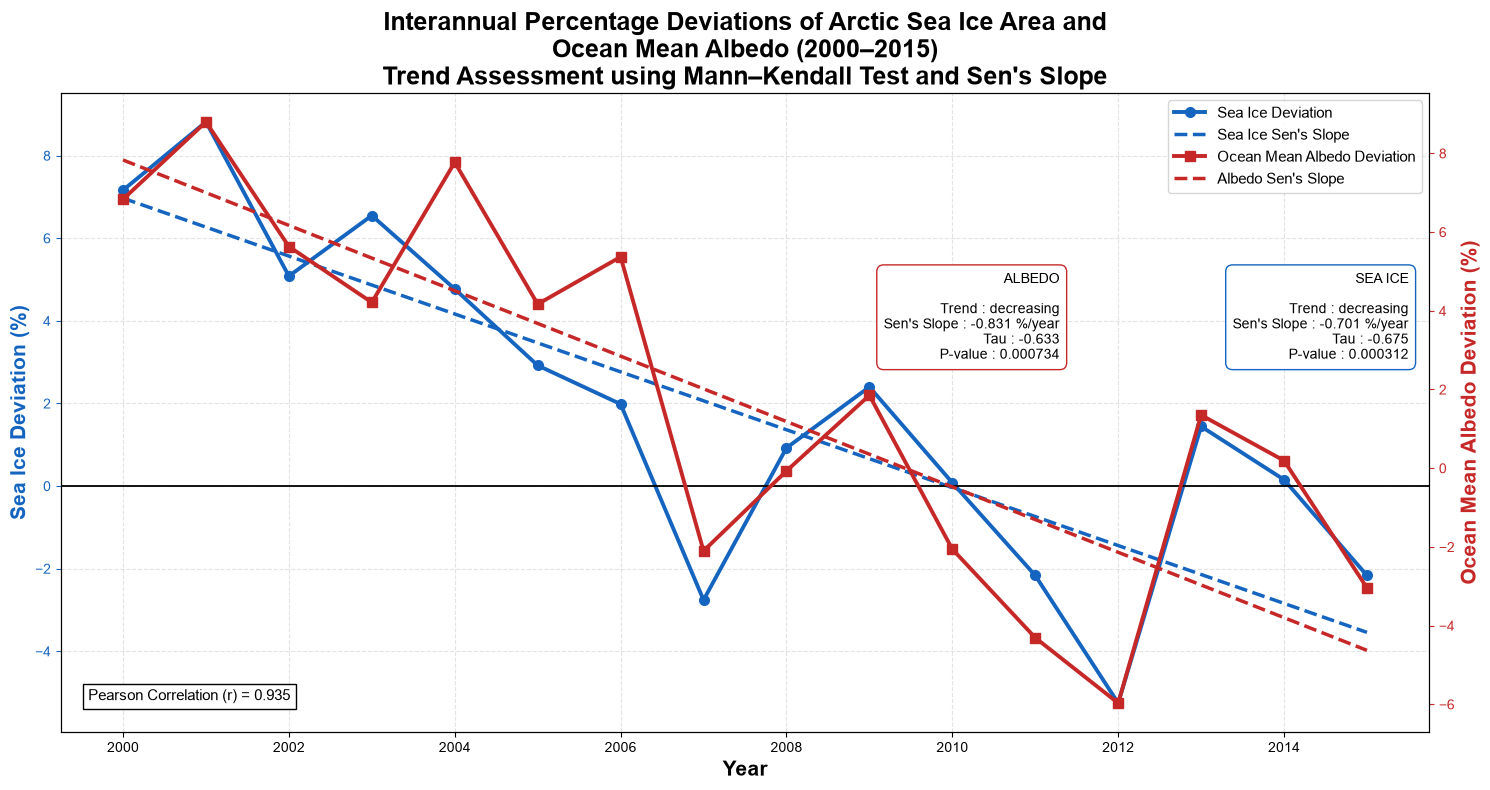

Publication Quality Figure Saved Successfully


In [17]:
# ============================================================
# PUBLICATION QUALITY FIGURE
# Mann–Kendall + Sen's Slope (2000–2015)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# ============================================================
# MANN-KENDALL
# ============================================================

sea_result = mk.original_test(df_period["Sea Ice Deviation (%)"])
alb_result = mk.original_test(df_period["Albedo Deviation (%)"])

# ============================================================
# SEN'S SLOPE TREND
# ============================================================

x = df_period["Year"].values
index = np.arange(len(df_period))

sea_sen = sea_result.intercept + sea_result.slope * index
alb_sen = alb_result.intercept + alb_result.slope * index

# ============================================================
# PEARSON CORRELATION
# ============================================================

corr = df_period["Sea Ice Deviation (%)"].corr(
    df_period["Albedo Deviation (%)"]
)

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(15,8))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(
    x,
    df_period["Sea Ice Deviation (%)"],
    marker="o",
    color="#1565C0",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Deviation"
)

ax1.plot(
    x,
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.5,
    label="Sea Ice Sen's Slope"
)

ax1.set_ylabel(
    "Sea Ice Deviation (%)",
    fontsize=15,
    color="#1565C0",
    fontweight="bold"
)

ax1.tick_params(
    axis="y",
    colors="#1565C0"
)

# ============================================================
# ZERO REFERENCE
# ============================================================

ax1.axhline(
    0,
    color="black",
    linewidth=1.3
)

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    df_period["Albedo Deviation (%)"],
    marker="s",
    color="#C62828",
    linewidth=2.8,
    markersize=7,
    label="Ocean Mean Albedo Deviation"
)

ax2.plot(
    x,
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.5,
    label="Albedo Sen's Slope"
)

ax2.set_ylabel(
    "Ocean Mean Albedo Deviation (%)",
    fontsize=15,
    color="#C62828",
    fontweight="bold"
)

ax2.tick_params(
    axis="y",
    colors="#C62828"
)

# ============================================================
# GRID
# ============================================================

ax1.grid(
    linestyle="--",
    alpha=0.35
)

# ============================================================
# LABELS
# ============================================================

ax1.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Interannual Percentage Deviations of Arctic Sea Ice Area and\n"
    "Ocean Mean Albedo (2000–2015)\n"
    "Trend Assessment using Mann–Kendall Test and Sen's Slope",
    fontsize=18,
    fontweight="bold"
)

# ============================================================
# LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    fontsize=11,
    frameon=True
)

# ============================================================
# SEA ICE BOX
# ============================================================

ax1.text(
    0.985,
    0.72,
    (
        "SEA ICE\n\n"
        f"Trend : {sea_result.trend}\n"
        f"Sen's Slope : {sea_result.slope:.3f} %/year\n"
        f"Tau : {sea_result.Tau:.3f}\n"
        f"P-value : {sea_result.p:.6f}"
    ),
    transform=ax1.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        boxstyle="round,pad=0.5"
    )
)

# ============================================================
# ALBEDO BOX
# ============================================================

ax2.text(
    0.73,
    0.72,
    (
        "ALBEDO\n\n"
        f"Trend : {alb_result.trend}\n"
        f"Sen's Slope : {alb_result.slope:.3f} %/year\n"
        f"Tau : {alb_result.Tau:.3f}\n"
        f"P-value : {alb_result.p:.6f}"
    ),
    transform=ax2.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        boxstyle="round,pad=0.5"
    )
)

# ============================================================
# CORRELATION BOX
# ============================================================

ax1.text(
    0.02,
    0.05,
    f"Pearson Correlation (r) = {corr:.3f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black"
    )
)

# ============================================================
# SAVE
# ============================================================

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS,
        "MK_Sen_SeaIce_Albedo_2000_2015.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("="*60)
print("Publication Quality Figure Saved Successfully")
print("="*60)

In [18]:
# ============================================================
# DATA : 2016-2025
# ============================================================

df_period = df[
    (df["Year"] >= 2016) &
    (df["Year"] <= 2025)
].copy()

print(df_period.shape)

print(df_period.head())

(10, 17)
    Year   March   April     May    June   July  August  September  \
16  2016  12.188  12.175  11.116   9.972  8.026   5.593      4.738   
17  2017  12.363  12.326  11.756  10.499  8.252   5.507      4.895   
18  2018  12.280  12.141  11.480  10.287  8.453   5.621      4.835   
19  2019  12.329  12.061  11.460  10.258  7.715   5.019      4.452   
20  2020  12.566  12.329  11.758  10.224  7.460   5.205      4.101   

    Yearly Mean  Minimum  Maximum  Standard Deviation  Ocean Mean Albedo  \
16        9.115    4.738   12.188               3.063             0.4355   
17        9.371    4.895   12.363               3.185             0.4531   
18        9.299    4.835   12.280               3.079             0.4527   
19        9.042    4.452   12.329               3.323             0.4379   
20        9.092    4.101   12.566               3.503             0.4282   

    Land Mean Albedo  Overall Mean Albedo  Sea Ice Deviation (%)  \
16            0.3724               0.4129    

In [19]:
# ============================================================
# DATA : 2016-2025
# ============================================================

df_period = df[
    (df["Year"] >= 2016) &
    (df["Year"] <= 2025)
].copy()

print(df_period.shape)

print(df_period.head())

(10, 17)
    Year   March   April     May    June   July  August  September  \
16  2016  12.188  12.175  11.116   9.972  8.026   5.593      4.738   
17  2017  12.363  12.326  11.756  10.499  8.252   5.507      4.895   
18  2018  12.280  12.141  11.480  10.287  8.453   5.621      4.835   
19  2019  12.329  12.061  11.460  10.258  7.715   5.019      4.452   
20  2020  12.566  12.329  11.758  10.224  7.460   5.205      4.101   

    Yearly Mean  Minimum  Maximum  Standard Deviation  Ocean Mean Albedo  \
16        9.115    4.738   12.188               3.063             0.4355   
17        9.371    4.895   12.363               3.185             0.4531   
18        9.299    4.835   12.280               3.079             0.4527   
19        9.042    4.452   12.329               3.323             0.4379   
20        9.092    4.101   12.566               3.503             0.4282   

    Land Mean Albedo  Overall Mean Albedo  Sea Ice Deviation (%)  \
16            0.3724               0.4129    

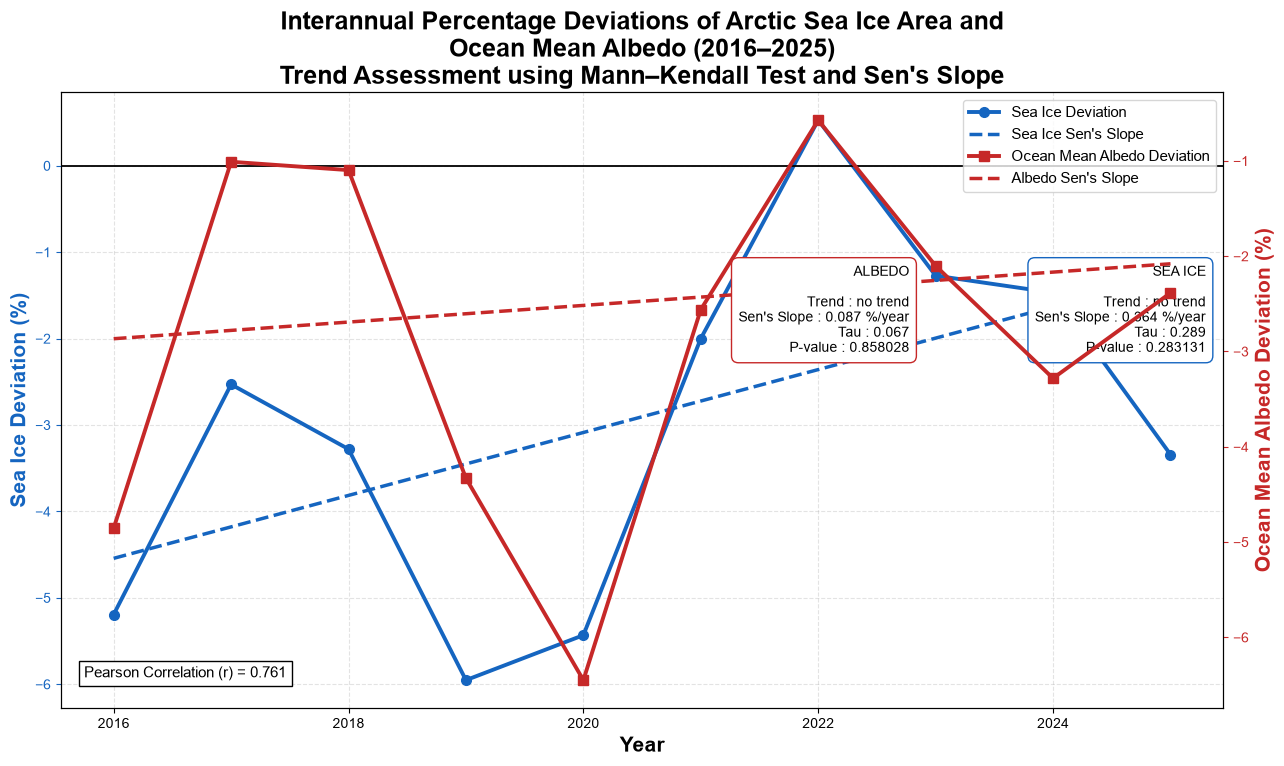

Publication Quality Figure Saved Successfully


In [20]:
# ============================================================
# PUBLICATION QUALITY FIGURE
# Mann–Kendall + Sen's Slope (2000–2015)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pymannkendall as mk

# ============================================================
# MANN-KENDALL
# ============================================================

sea_result = mk.original_test(df_period["Sea Ice Deviation (%)"])
alb_result = mk.original_test(df_period["Albedo Deviation (%)"])

# ============================================================
# SEN'S SLOPE TREND
# ============================================================

x = df_period["Year"].values
index = np.arange(len(df_period))

sea_sen = sea_result.intercept + sea_result.slope * index
alb_sen = alb_result.intercept + alb_result.slope * index

# ============================================================
# PEARSON CORRELATION
# ============================================================

corr = df_period["Sea Ice Deviation (%)"].corr(
    df_period["Albedo Deviation (%)"]
)

# ============================================================
# FIGURE
# ============================================================

plt.rcParams["font.family"] = "Arial"

fig, ax1 = plt.subplots(figsize=(15,8))

# ============================================================
# SEA ICE
# ============================================================

ax1.plot(
    x,
    df_period["Sea Ice Deviation (%)"],
    marker="o",
    color="#1565C0",
    linewidth=2.8,
    markersize=7,
    label="Sea Ice Deviation"
)

ax1.plot(
    x,
    sea_sen,
    "--",
    color="#1565C0",
    linewidth=2.5,
    label="Sea Ice Sen's Slope"
)

ax1.set_ylabel(
    "Sea Ice Deviation (%)",
    fontsize=15,
    color="#1565C0",
    fontweight="bold"
)

ax1.tick_params(
    axis="y",
    colors="#1565C0"
)

# ============================================================
# ZERO REFERENCE
# ============================================================

ax1.axhline(
    0,
    color="black",
    linewidth=1.3
)

# ============================================================
# ALBEDO
# ============================================================

ax2 = ax1.twinx()

ax2.plot(
    x,
    df_period["Albedo Deviation (%)"],
    marker="s",
    color="#C62828",
    linewidth=2.8,
    markersize=7,
    label="Ocean Mean Albedo Deviation"
)

ax2.plot(
    x,
    alb_sen,
    "--",
    color="#C62828",
    linewidth=2.5,
    label="Albedo Sen's Slope"
)

ax2.set_ylabel(
    "Ocean Mean Albedo Deviation (%)",
    fontsize=15,
    color="#C62828",
    fontweight="bold"
)

ax2.tick_params(
    axis="y",
    colors="#C62828"
)

# ============================================================
# GRID
# ============================================================

ax1.grid(
    linestyle="--",
    alpha=0.35
)

# ============================================================
# LABELS
# ============================================================

ax1.set_xlabel(
    "Year",
    fontsize=15,
    fontweight="bold"
)

# ============================================================
# TITLE
# ============================================================

plt.title(
    "Interannual Percentage Deviations of Arctic Sea Ice Area and\n"
    "Ocean Mean Albedo (2016–2025)\n"
    "Trend Assessment using Mann–Kendall Test and Sen's Slope",
    fontsize=18,
    fontweight="bold"
)

# ============================================================
# LEGEND
# ============================================================

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

legend = ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right",
    fontsize=11,
    frameon=True
)

# ============================================================
# SEA ICE BOX
# ============================================================

ax1.text(
    0.985,
    0.72,
    (
        "SEA ICE\n\n"
        f"Trend : {sea_result.trend}\n"
        f"Sen's Slope : {sea_result.slope:.3f} %/year\n"
        f"Tau : {sea_result.Tau:.3f}\n"
        f"P-value : {sea_result.p:.6f}"
    ),
    transform=ax1.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="#1565C0",
        boxstyle="round,pad=0.5"
    )
)

# ============================================================
# ALBEDO BOX
# ============================================================

ax2.text(
    0.73,
    0.72,
    (
        "ALBEDO\n\n"
        f"Trend : {alb_result.trend}\n"
        f"Sen's Slope : {alb_result.slope:.3f} %/year\n"
        f"Tau : {alb_result.Tau:.3f}\n"
        f"P-value : {alb_result.p:.6f}"
    ),
    transform=ax2.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    bbox=dict(
        facecolor="white",
        edgecolor="#C62828",
        boxstyle="round,pad=0.5"
    )
)

# ============================================================
# CORRELATION BOX
# ============================================================

ax1.text(
    0.02,
    0.05,
    f"Pearson Correlation (r) = {corr:.3f}",
    transform=ax1.transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black"
    )
)

# ============================================================
# SAVE
# ============================================================
plt.savefig(
    os.path.join(
        RESULTS,
        "MK_Sen_SeaIce_Albedo_2016_2025.png"
    ),
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("="*60)
print("Publication Quality Figure Saved Successfully")
print("="*60)

In [21]:
print(df_period[["Year",
                 "Sea Ice Deviation (%)",
                 "Albedo Deviation (%)"]])

    Year  Sea Ice Deviation (%)  Albedo Deviation (%)
16  2016              -5.193002             -4.854336
17  2017              -2.530294             -1.009184
18  2018              -3.279180             -1.096574
19  2019              -5.952290             -4.329997
20  2020              -5.432230             -6.449200
21  2021              -1.999832             -2.560354
22  2022               0.527661             -0.572235
23  2023              -1.271748             -2.101557
24  2024              -1.469370             -3.281320
25  2025              -3.341588             -2.385574


In [22]:
print(sea_result)

print("Slope :", sea_result.slope)
print("Intercept :", sea_result.intercept)

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.28313087066234655), z=np.float64(1.073312629199899), Tau=np.float64(0.28888888888888886), s=np.float64(13.0), var_s=125.0, slope=np.float64(0.36404222889855375), intercept=np.float64(-4.542926979529639))
Slope : 0.36404222889855375
Intercept : -4.542926979529639


In [23]:
from scipy.stats import linregress

x = df_period["Year"]

y = df_period["Sea Ice Deviation (%)"]

lr = linregress(x, y)

print("Linear Regression slope =", lr.slope)

Linear Regression slope = 0.3454461323574139


In [31]:
# Long-term means
sea_long_mean = df["Yearly Mean"].mean()
albedo_long_mean = df["Ocean Mean Albedo"].mean()

# Percentage deviations
df["Sea Ice Deviation (%)"] = (
    (df["Yearly Mean"] - sea_long_mean)
    / sea_long_mean
) * 100

df["Albedo Deviation (%)"] = (
    (df["Ocean Mean Albedo"] - albedo_long_mean)
    / albedo_long_mean
) * 100

In [32]:
print(df.columns)

Index(['Year', 'March', 'April', 'May', 'June', 'July', 'August', 'September',
       'Yearly Mean', 'Minimum', 'Maximum', 'Standard Deviation',
       'Ocean Mean Albedo', 'Land Mean Albedo', 'Overall Mean Albedo',
       'Sea Ice Deviation (%)', 'Albedo Deviation (%)'],
      dtype='str')


In [33]:
sea_result = mk.original_test(df["Sea Ice Deviation (%)"])
alb_result = mk.original_test(df["Albedo Deviation (%)"])

print(sea_result)
print(alb_result)

Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(6.593688664424668e-05), z=np.float64(-3.990490153550879), Tau=np.float64(-0.56), s=np.float64(-182.0), var_s=np.float64(2057.3333333333335), slope=np.float64(-0.4363553791287409), intercept=np.float64(4.858773141493935))
Mann_Kendall_Test(trend='decreasing', h=np.True_, p=np.float64(0.00011422109125835966), z=np.float64(-3.8582087119967063), Tau=np.float64(-0.5415384615384615), s=np.float64(-176.0), var_s=np.float64(2057.3333333333335), slope=np.float64(-0.42056349626492556), intercept=np.float64(4.204164460914075))


In [26]:
mk_df = pd.DataFrame({
    "Variable": ["Sea Ice", "Ocean Mean Albedo"],
    "Trend": [sea_result.trend, alb_result.trend],
    "Sen's Slope": [sea_result.slope, alb_result.slope],
    "Tau": [sea_result.Tau, alb_result.Tau],
    "P-value": [sea_result.p, alb_result.p],
    "Z": [sea_result.z, alb_result.z],
    "S": [sea_result.s, alb_result.s],
})

with pd.ExcelWriter("Master_Dataset_Final.xlsx", engine="openpyxl", mode="w") as writer:
    mk_df.to_excel(writer, sheet_name="MK_Test_Results", index=False)

In [27]:
print(df["Year"].min())
print(df["Year"].max())
print(df.shape)

2000
2025
(26, 15)


In [28]:
print(df.columns.tolist())

['Year', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'Yearly Mean', 'Minimum', 'Maximum', 'Standard Deviation', 'Ocean Mean Albedo', 'Land Mean Albedo', 'Overall Mean Albedo']


In [29]:
print(df[["Year",
          "Sea Ice Deviation (%)",
          "Albedo Deviation (%)"]].head())

KeyError: "['Sea Ice Deviation (%)', 'Albedo Deviation (%)'] not in index"

In [30]:
print(df["Sea Ice Deviation (%)"].values)

KeyError: 'Sea Ice Deviation (%)'